In [1]:
# ai.page

In [2]:
def transform_tukey(SERIE):
  return np.arcsin(np.sqrt(SERIE))

In [3]:
import re
import numpy as np
import matplotlib.pyplot as plt
import numpy as numpy
import seaborn as sns
import pandas as pandas
import statsmodels.api as sm
import statsmodels.formula.api as smf # Formula = 'y~x'

In [4]:
%matplotlib inline

In [5]:
df = pandas.read_csv("https://raw.githubusercontent.com/it-ces/Datasets/refs/heads/main/data-gapminder.csv")

In [6]:
df.head()

,country,incomeperperson,alcconsumption,armedforcesrate,breastcancerper100th,co2emissions,femaleemployrate,hivrate,internetuserate,lifeexpectancy,oilperperson,polityscore,relectricperperson,suicideper100th,employrate,urbanrate
0,Afghanistan,,.03,.5696534,26.8,75944000,25.6000003814697,,3.65412162280064,48.673,,0,,6.68438529968262,55.7000007629394,24.04
1,Albania,1914.99655094922,7.29,1.0247361,57.4,223747333.333333,42.0999984741211,,44.9899469578783,76.918,,9,636.341383366604,7.69932985305786,51.4000015258789,46.72
2,Algeria,2231.99333515006,.69,2.306817,23.5,2932108666.66667,31.7000007629394,.1,12.5000733055148,73.131,.42009452521537,2,590.509814347428,4.8487696647644,50.5,65.22
3,Andorra,21943.3398976022,10.17,,,,,,81,,,,,5.36217880249023,,88.92
4,Angola,1381.00426770244,5.57,1.4613288,23.1,248358000,69.4000015258789,2,9.99995388324075,51.093,,-2,172.999227388199,14.5546770095825,75.6999969482422,56.7


In [7]:
df.columns

Index(['country', 'incomeperperson', 'alcconsumption', 'armedforcesrate',
       'breastcancerper100th', 'co2emissions', 'femaleemployrate', 'hivrate',
       'internetuserate', 'lifeexpectancy', 'oilperperson', 'polityscore',
       'relectricperperson', 'suicideper100th', 'employrate', 'urbanrate'],
      dtype='object')

In [8]:
df.dtypes

,0
country,object
incomeperperson,object
alcconsumption,object
armedforcesrate,object
breastcancerper100th,object
co2emissions,object
femaleemployrate,object
hivrate,object
internetuserate,object
lifeexpectancy,object


In [9]:
df['urbanrate'].head()

,urbanrate
0,24.04
1,46.72
2,65.22
3,88.92
4,56.7


In [10]:
pattern = '[^\d.]'
booleans  = df['internetuserate'].apply(lambda x: ''.join(re.findall(pattern, x))) != ''

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_4535/2845106864.py:1: SyntaxWarning: invalid escape sequence '\d'
  pattern = '[^\d.]'


In [11]:
df['internetuserate'][booleans] # le dejaron espacios en blanco

,internetuserate
43,
75,
76,
99,
120,
121,
127,
132,
134,
137,


Text(0.5, 1.0, 'Income per capita and Internet Use Rate')

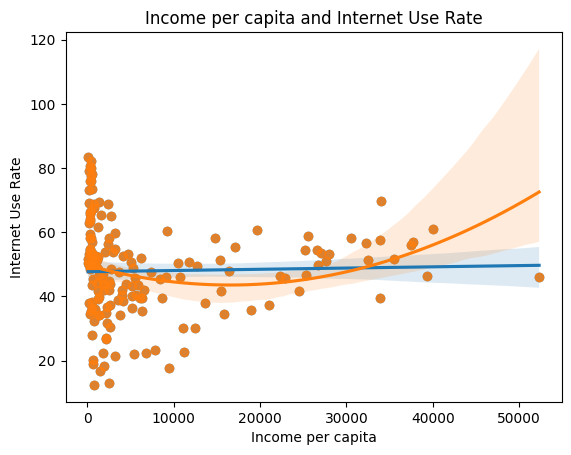

In [12]:
df['internetuserate'] = pandas.to_numeric(df['internetuserate'], errors='coerce')
df['urbanrate'] = pandas.to_numeric(df['urbanrate'], errors='coerce')
df['incomeperperson']  = pandas.to_numeric(df['incomeperperson'], errors='coerce')
df['femaleemployrate'] = pandas.to_numeric(df['femaleemployrate'], errors='coerce')
sns.regplot(x="incomeperperson", y="femaleemployrate", scatter=True, order=1, data=df)
sns.regplot(x="incomeperperson", y="femaleemployrate", scatter=True, order=2, data=df)
plt.xlabel('Income per capita')
plt.ylabel('Internet Use Rate')
plt.title ('Income per capita and Internet Use Rate')

<Axes: xlabel='lnincome', ylabel='femaleemployrate'>

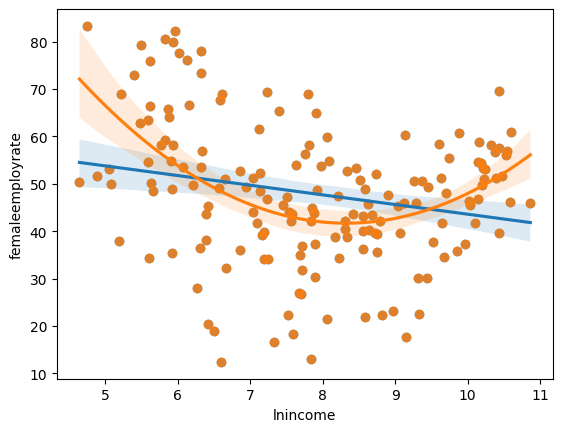

In [13]:
# logaritmo
df['lnincome'] = np.log(df['incomeperperson'])
sns.regplot(x="lnincome", y="femaleemployrate", scatter=True, order=1, data=df)
sns.regplot(x="lnincome", y="femaleemployrate", scatter=True, order=2, data=df)

In [14]:
print(smf.ols(formula='femaleemployrate ~ lnincome', data=df).fit().summary())

                            OLS Regression Results                            
Dep. Variable:       femaleemployrate   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.045
Method:                 Least Squares   F-statistic:                     8.696
Date:                Sun, 12 Apr 2026   Prob (F-statistic):            0.00365
Time:                        05:05:29   Log-Likelihood:                -676.01
No. Observations:                 166   AIC:                             1356.
Df Residuals:                     164   BIC:                             1362.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     63.9544      5.535     11.555      0.0

# U - shaped economic growth and woman in labor force

# Hypothesis
the main idea is that the economic growth and labor force female are related quadratically.
$$ y = \beta_{0} + \beta_{1} x_{1} + \beta_{2} x_{1}^{2} + u $$

<Axes: xlabel='lnincome', ylabel='femaleemployrate'>

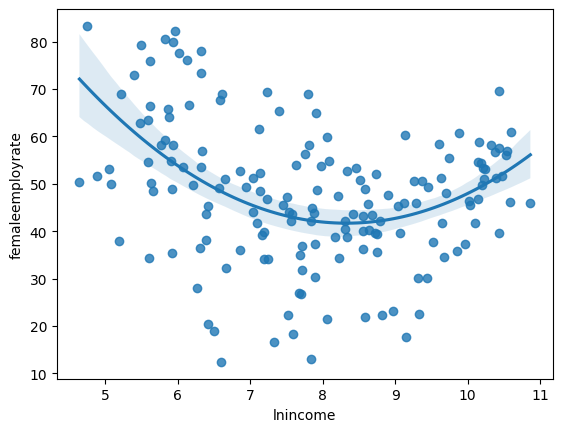

In [15]:
sns.regplot(x = 'lnincome', y='femaleemployrate', order = 2,  data=df) # la naranja

In [16]:
# I (identity function) returns that is inside of paranthesis
print(smf.ols(formula = 'femaleemployrate ~ lnincome + I(lnincome**2)', data = df).fit().summary())

                            OLS Regression Results                            
Dep. Variable:       femaleemployrate   R-squared:                       0.199
Model:                            OLS   Adj. R-squared:                  0.189
Method:                 Least Squares   F-statistic:                     20.26
Date:                Sun, 12 Apr 2026   Prob (F-statistic):           1.38e-08
Time:                        05:05:29   Log-Likelihood:                -661.87
No. Observations:                 166   AIC:                             1330.
Df Residuals:                     163   BIC:                             1339.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          196.9957     24.710  

In [17]:
# See that the varriables are statistically significant

In [18]:
# Now study residuals!

# Q-Q plot

Q-Q plot allow us answer the following question the variables $X$ and $Y$ have the same features (mean variance)?

then organize $(x_{\theta}, y_{\theta})$ where $\theta$ is the $\theta$-ith quantile. you can uses percentile! if both variables come from variables with same features, then appear a straight line!

in our problem make it the comparation between the empirical data with the normal distribution.



Make some examples,  using different population using **numpy.random**. make simulations for understand better change the size of sample!

In [19]:
model  = smf.ols(formula = 'femaleemployrate ~ lnincome + I(lnincome**2)', data=df).fit()

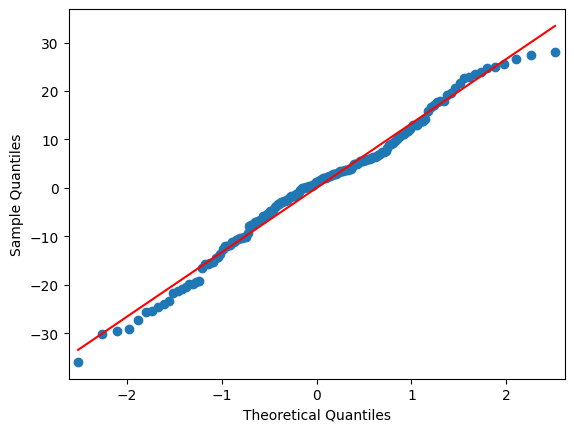

In [20]:
sm.qqplot(model.resid, line='r')
plt.show()
# Assesing errors normally distributed!

In [21]:
from scipy.stats import shapiro
shapiro(model.resid).pvalue

np.float64(0.08510422689965506)

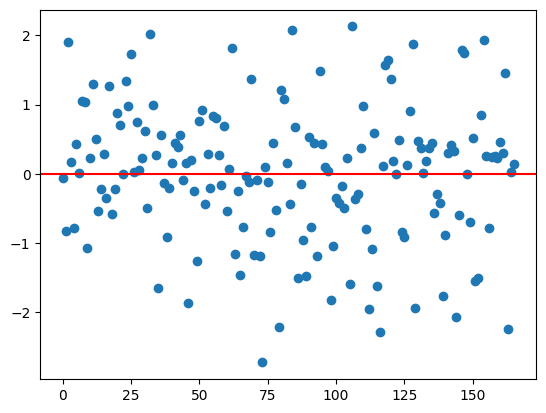

In [22]:
plt.plot(model.resid_pearson, 'o') # standardized  errrors to fit a normal distribution
plt.axhline(y= 0, color='red') # each observation agains its standardized residual
# you expect the empircal rule!,
# you can also check here outliers!
#rule of thumb: if more than 5% of points, have and absolute value of std errors  with 2.5 or more, then review your model
# homocedasticity check (the varince betweeen residuals must be constant)

In [23]:
# To check homocedasticity one plot is residuals vs fitted values
# you can plot residuals vs predictor

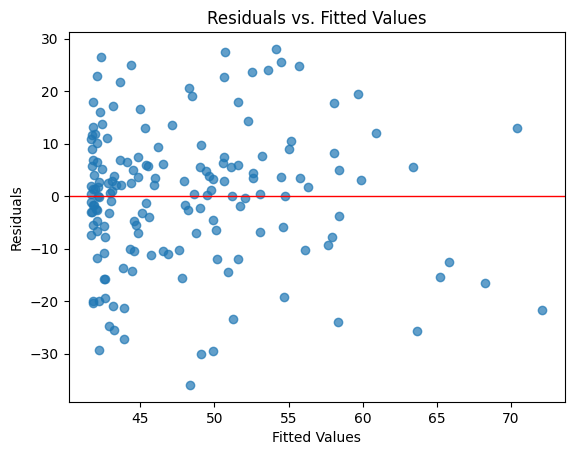

In [24]:
# Extract fitted values and residuals
fitted_vals = model.fittedvalues  # Predicted values
residuals = model.resid           # Residuals

# Plot residuals vs. fitted values
plt.scatter(fitted_vals, residuals, alpha=0.7)
plt.axhline(0, color='red',linewidth=1)
plt.title('Residuals vs. Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

In [25]:
# Breush pagan test
# H0: homocedasticidad
# H1: heterocedasticidad
from statsmodels.stats.diagnostic import het_breuschpagan
residuals = model.resid
exog = model.model.exog  # The design matrix (predictor variables with intercept)
bp_test = het_breuschpagan(residuals, exog)
print("p-value:", bp_test[1])

p-value: 0.0004653828486090881


In [26]:
from statsmodels.stats.diagnostic import acorr_breusch_godfrey
# remember H0 (there is not autocorrelation)
# H1 (theres is autocorrelation)
bg_test = acorr_breusch_godfrey(model, nlags=1)
bg_test[1] # p-value

np.float64(0.45803918674502775)

# transformación angular - tukey

$$ y = arcsin\sqrt{x}$$

In [27]:
df['femaleemployrate'] = df['femaleemployrate']/100

In [28]:
df['tukey_femaleemployrate']   = transform_tukey(df['femaleemployrate'])

In [29]:
model = smf.ols('tukey_femaleemployrate ~ lnincome + I(lnincome**2)', data = df).fit()

In [30]:
shapiro(model.resid).pvalue

# HOMOCEDASTICIDAD
residuals = model.resid
exog = model.model.exog  # The design matrix (predictor variables with intercept)
bp_test = het_breuschpagan(residuals, exog)
print("p-value:", bp_test[1])

bg_test = acorr_breusch_godfrey(model, nlags=1)
bg_test[1] # p-value

p-value: 0.0006664036545589093


np.float64(0.47286431303203347)

In [31]:
# corregir la heterocedasticidad!! estamos modelando con el operador del sandiwch!
model = smf.ols('femaleemployrate ~ lnincome + I(lnincome**2)', data = df).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       femaleemployrate   R-squared:                       0.199
Model:                            OLS   Adj. R-squared:                  0.189
Method:                 Least Squares   F-statistic:                     15.58
Date:                Sun, 12 Apr 2026   Prob (F-statistic):           6.41e-07
Time:                        05:05:30   Log-Likelihood:                 102.59
No. Observations:                 166   AIC:                            -199.2
Df Residuals:                     163   BIC:                            -189.8
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            1.9700      0.269  